# Attenuation Bias in Regression with Measurement Errors

This tutorial provides a pedagogical introduction to **attenuation bias**—the systematic underestimation of the dynamic range of predictions when input variables are measured with error. We demonstrate that neural networks exhibit the same bias as linear regression, and introduce **LatentNN**, a method that corrects this bias by treating the true input values as latent variables.

For theoretical background, see [Ting et al. (2025)](https://arxiv.org/abs/placeholder).

---
## 1. Setup

We import the necessary libraries and configure the plotting style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
from joblib import Parallel, delayed

from latentnn import (
    train_mlp, train_latent_mlp,
    predict_mlp, predict_latent,
    generate_data, calc_lambda, theoretical_attenuation
)

np.random.seed(52)
torch.manual_seed(52)

# Parallelization settings (for stable results)
N_JOBS = 8   # Number of parallel workers
N_SIMS = 8   # Number of simulations per configuration

# Plotting style (matching paper figures)
plt.rc('text', usetex=False)
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 16,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Colorblind-friendly palette
CB_BLUE = '#4477AA'
CB_RED = '#EE6677'
CB_GREEN = '#228833'
CB_ORANGE = '#CCBB44'

print('Setup complete')

Setup complete


---
## 2. The Problem: Attenuation Bias

Consider a simple linear relationship:

$$y_{\mathrm{true}} = 2 x_{\mathrm{true}}$$

In practice, we observe noisy measurements:

$$x_{\mathrm{obs}} = x_{\mathrm{true}} + \delta_x, \quad \delta_x \sim \mathcal{N}(0, \sigma_x^2)$$

$$y_{\mathrm{obs}} = y_{\mathrm{true}} + \delta_y, \quad \delta_y \sim \mathcal{N}(0, \sigma_y^2)$$

When we fit a regression model treating $x_{\mathrm{obs}}$ as the true input, the estimated slope is systematically biased toward zero. This is **attenuation bias** (also called regression dilution).

We generate synthetic data with $\mathrm{SNR}_x = 1$ (measurement error equals signal range) to visualize this effect clearly.

In [2]:
data = generate_data(n_samples=100, snr_x=1.0, snr_y=10, seed=52)

print(f'True x range: [{data["x_true"].min():.2f}, {data["x_true"].max():.2f}]')
print(f'σ_x = {data["sigma_x"]:.3f}')
print(f'σ_y = {data["sigma_y"]:.3f}')

True x range: [-4.96, 4.94]
σ_x = 2.832
σ_y = 0.566


### Visualizing the Bias

The figure below shows the effect of measurement error on the fitted relationship. Gray arrows indicate how each point is displaced horizontally by the measurement error in $x$. When we fit a line to the observed data $(x_{\mathrm{obs}}, y)$, we obtain a shallower slope than the true relationship.

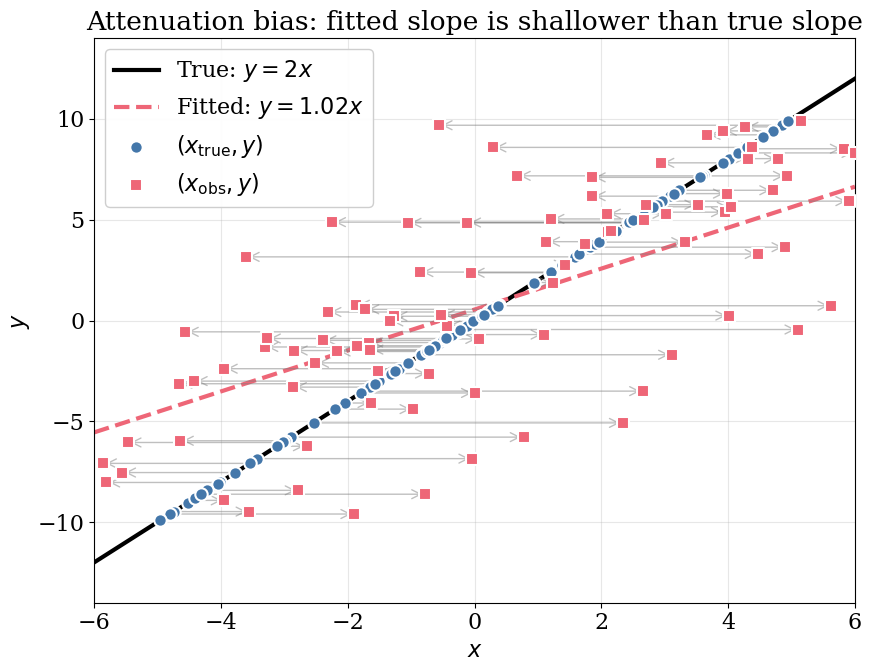

True slope:     2.000
Fitted slope:   1.016
Attenuation λ:  0.508


In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(data['x_obs'].reshape(-1, 1), data['y_true'])
fitted_slope = lr.coef_[0]

fig, ax = plt.subplots(figsize=(9, 7))
x_line = np.linspace(-6, 6, 100)

# True and fitted relationships
ax.plot(x_line, 2 * x_line, 'k-', lw=3, label='True: $y = 2x$')
ax.plot(x_line, lr.predict(x_line.reshape(-1, 1)), '--', color=CB_RED, lw=3,
        label=f'Fitted: $y = {fitted_slope:.2f}x$')

# Displacement arrows
for i in range(len(data['x_true'])):
    ax.annotate('', xy=(data['x_obs'][i], data['y_true'][i]),
                xytext=(data['x_true'][i], data['y_true'][i]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.5))

# Data points
ax.scatter(data['x_true'], data['y_true'], s=80, c=CB_BLUE, edgecolors='white', lw=1.5,
           label='$(x_{\\mathrm{true}}, y)$', zorder=10)
ax.scatter(data['x_obs'], data['y_true'], s=80, c=CB_RED, edgecolors='white', lw=1.5,
           marker='s', label='$(x_{\\mathrm{obs}}, y)$', zorder=10)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-6, 6)
ax.set_ylim(-14, 14)
ax.legend(loc='upper left', framealpha=0.95)
ax.set_title('Attenuation bias: fitted slope is shallower than true slope')
plt.tight_layout()
plt.show()

print(f'True slope:     2.000')
print(f'Fitted slope:   {fitted_slope:.3f}')
print(f'Attenuation λ:  {fitted_slope/2:.3f}')

### The Attenuation Factor

For linear regression with Gaussian measurement errors, the expected attenuation has a closed form:

$$\lambda = \frac{\sigma_{\mathrm{range}}^2}{\sigma_{\mathrm{range}}^2 + \sigma_x^2} = \frac{1}{1 + 1/\mathrm{SNR}_x^2}$$

where $\mathrm{SNR}_x = \sigma_{\mathrm{range}} / \sigma_x$ is the signal-to-noise ratio. The attenuation factor $\lambda \in (0, 1]$, with $\lambda = 1$ corresponding to perfect measurements and $\lambda \to 0$ as noise dominates.

In [4]:
print('SNR_x    λ (theory)    Bias')
print('-' * 35)
for snr in [0.5, 1, 2, 3, 5, 10]:
    lam = theoretical_attenuation(snr)
    print(f'{snr:5.1f}      {lam:.3f}       {(1-lam)*100:5.1f}%')

SNR_x    λ (theory)    Bias
-----------------------------------
  0.5      0.200        80.0%
  1.0      0.500        50.0%
  2.0      0.800        20.0%
  3.0      0.900        10.0%
  5.0      0.962         3.8%
 10.0      0.990         1.0%


At $\mathrm{SNR}_x = 1$, the bias is 50%—the estimated slope is half the true value. Even at $\mathrm{SNR}_x = 3$, there is a 10% bias. In astronomy, where we often work with SNR in this range, attenuation bias can significantly affect our conclusions.

---
## 3. Neural Networks Exhibit the Same Bias

One might expect that neural networks, being more flexible than linear regression, could learn to correct for measurement error. However, standard neural networks trained by minimizing squared error exhibit the same attenuation bias.

This occurs because the optimization objective

$$\mathcal{L} = \sum_i \left( y_{\mathrm{obs},i} - f_\theta(x_{\mathrm{obs},i}) \right)^2$$

treats $x_{\mathrm{obs}}$ as the true input. The model has no information about the measurement error structure, so it cannot correct for it regardless of its capacity.

In [5]:
# NOTE: For faster execution, we use a smaller network (16 nodes) and fewer epochs (5000).
#       For better results matching the paper, use hidden_size=64, epochs=20000.

N_TRAIN, N_TEST = 1000, 200
SNR_Y = 30
snr_x_values = np.array([1, 2, 3, 5, 10])
lambda_mlp = []

print('Training MLPs at different SNR values...')
for snr_x in snr_x_values:
    data = generate_data(N_TRAIN + N_TEST, snr_x, SNR_Y, seed=42)
    x_train, x_test = data['x_obs'][:N_TRAIN], data['x_obs'][N_TRAIN:]
    y_train = data['y_obs'][:N_TRAIN]
    y_true_test = data['y_true'][N_TRAIN:]
    
    torch.manual_seed(42)
    model = train_mlp(x_train, y_train, 
                      hidden_size=16, num_layers=2,
                      epochs=5000, lr=0.03, weight_decay=0.01)
    
    y_pred = predict_mlp(model, x_test)
    lam, _ = calc_lambda(y_true_test, y_pred)
    lambda_mlp.append(lam)
    
    print(f'  SNR_x = {snr_x:2d}:  λ = {lam:.3f}  (theory: {theoretical_attenuation(snr_x):.3f})')

Training MLPs at different SNR values...
  SNR_x =  1:  λ = 0.529  (theory: 0.500)
  SNR_x =  2:  λ = 0.817  (theory: 0.800)
  SNR_x =  3:  λ = 0.901  (theory: 0.900)
  SNR_x =  5:  λ = 0.966  (theory: 0.962)
  SNR_x = 10:  λ = 0.991  (theory: 0.990)


### Comparison with Theory

The plot below shows that the MLP attenuation closely follows the theoretical curve derived for linear regression. The key insight is that model flexibility, regularization, and additional training data do not correct attenuation bias—it is a fundamental consequence of treating noisy observations as exact inputs.

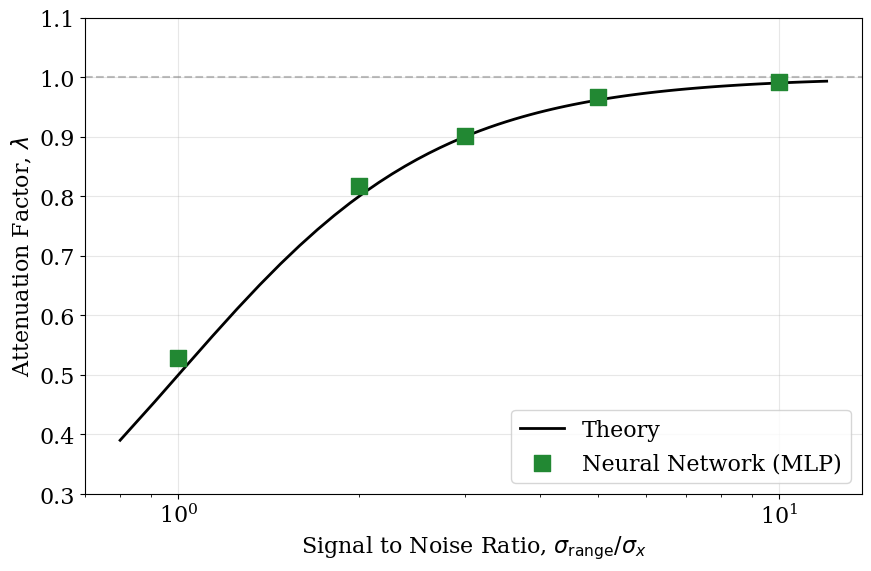

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

snr_theory = np.linspace(0.8, 12, 100)
ax.plot(snr_theory, [theoretical_attenuation(s) for s in snr_theory],
        'k-', lw=2, label='Theory')
ax.scatter(snr_x_values, lambda_mlp, s=120, c=CB_GREEN, marker='s',
           label='Neural Network (MLP)', zorder=5)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Signal to Noise Ratio, $\\sigma_{\\mathrm{range}} / \\sigma_x$')
ax.set_ylabel('Attenuation Factor, $\\lambda$')
ax.set_xscale('log')
ax.set_ylim(0.3, 1.1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 4. The LatentNN Method

LatentNN corrects attenuation bias by treating the true input values as **latent variables** to be estimated alongside the network parameters. Instead of the standard loss, LatentNN optimizes:

$$\mathcal{L} = \frac{1}{\sigma_y^2} \sum_i \left( y_{\mathrm{obs},i} - f_\theta(x_{\mathrm{latent},i}) \right)^2 + \frac{1}{\sigma_x^2} \sum_i \left( x_{\mathrm{obs},i} - x_{\mathrm{latent},i} \right)^2$$

where:
- $x_{\mathrm{latent},i}$ are learnable parameters, one per training sample, initialized at $x_{\mathrm{obs},i}$
- The first term encourages accurate predictions
- The second term regularizes latent values to stay close to observations
- The ratio $\sigma_y^2 / \sigma_x^2$ balances these objectives

This formulation corresponds to maximum a posteriori (MAP) estimation in an errors-in-variables model.

### Hyperparameter Tuning: weight_decay

The `weight_decay` parameter regularizes the network weights (but not the latent values). Finding the right value is critical: too small leads to overcorrection ($\lambda > 1$), too large leads to undercorrection ($\lambda < 1$). We search over multiple values and select the one that gives $\lambda$ closest to 1 on the validation set.

### Demonstration at Low SNR

We demonstrate LatentNN at $\mathrm{SNR}_x = 2$, where standard methods suffer ~20% attenuation. We use a three-way data split (train/validation/test) to avoid data leakage: hyperparameters are tuned on the validation set, and final evaluation uses only the test set.

In [7]:
SNR_X = 2.0
SNR_Y = 30.0
N_TRAIN, N_VAL, N_TEST = 1000, 200, 200

data = generate_data(N_TRAIN + N_VAL + N_TEST, SNR_X, SNR_Y, seed=52)

train = {k: v[:N_TRAIN] for k, v in data.items() if isinstance(v, np.ndarray)}
val = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data.items() if isinstance(v, np.ndarray)}
test = {k: v[N_TRAIN+N_VAL:] for k, v in data.items() if isinstance(v, np.ndarray)}
sigma_x, sigma_y = data['sigma_x'], data['sigma_y']

print(f'Data: {N_TRAIN} train, {N_VAL} val, {N_TEST} test')
print(f'σ_x = {sigma_x:.3f}, σ_y = {sigma_y:.3f}')

Data: 1000 train, 200 val, 200 test
σ_x = 1.451, σ_y = 0.193


In [8]:
# Network architecture parameters
# NOTE: For faster execution, we use a smaller network (16 nodes) and fewer epochs (5000).
#       For better results matching the paper, use hidden_size=64, epochs=20000.
HIDDEN_SIZE = 16
NUM_LAYERS = 2
EPOCHS = 5000
LR = 0.03

# Train standard MLP
print('Training Standard MLP...')
torch.manual_seed(42)
model_mlp = train_mlp(
    train['x_obs'], train['y_obs'],
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    epochs=EPOCHS, lr=LR, weight_decay=0.01
)

Training Standard MLP...


In [9]:
# Search for best weight_decay for LatentNN
print('Searching weight_decay for LatentNN...')
weight_decays = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
best_wd, best_lam = None, 0

for wd in weight_decays:
    torch.manual_seed(52)
    model = train_latent_mlp(
        train['x_obs'], train['y_obs'], sigma_x, sigma_y,
        hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
        epochs=EPOCHS, lr=LR, weight_decay=wd,
        x_val=val['x_obs'], y_true_val=val['y_true']
    )
    lam, _ = calc_lambda(val['y_true'], predict_latent(model, val['x_obs']))
    print(f'  wd={wd:.4f}: λ_val={lam:.4f}')
    
    # Select weight_decay giving λ closest to 1
    if best_wd is None or abs(lam - 1.0) < abs(best_lam - 1.0):
        best_wd, best_lam = wd, lam

print(f'Best weight_decay = {best_wd}')

# Train final model with best weight_decay
print('\nTraining final LatentNN with best weight_decay...')
torch.manual_seed(52)
model_latent, losses = train_latent_mlp(
    train['x_obs'], train['y_obs'], sigma_x, sigma_y,
    hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    epochs=EPOCHS, lr=LR, weight_decay=best_wd,
    x_val=val['x_obs'], y_true_val=val['y_true'],
    return_losses=True
)

Searching weight_decay for LatentNN...
  wd=0.0001: λ_val=0.9761
  wd=0.0003: λ_val=0.9793
  wd=0.0010: λ_val=0.9702
  wd=0.0030: λ_val=0.9698
  wd=0.0100: λ_val=0.9653
  wd=0.0300: λ_val=0.9564
  wd=0.1000: λ_val=0.9380
Best weight_decay = 0.0003

Training final LatentNN with best weight_decay...


### Evaluation on Test Set

We evaluate both models on the held-out test set and measure the attenuation factor $\lambda$. A value of $\lambda = 1$ indicates no attenuation (unbiased predictions).

In [10]:
y_pred_mlp = predict_mlp(model_mlp, test['x_obs'])
y_pred_latent = predict_latent(model_latent, test['x_obs'])

lam_mlp, int_mlp = calc_lambda(test['y_true'], y_pred_mlp)
lam_latent, int_latent = calc_lambda(test['y_true'], y_pred_latent)

print(f'Standard MLP:  λ = {lam_mlp:.3f}')
print(f'LatentNN:      λ = {lam_latent:.3f}')

Standard MLP:  λ = 0.798
LatentNN:      λ = 0.974


### Visual Comparison

The scatter plots below show $y_{\mathrm{pred}}$ vs $y_{\mathrm{true}}$ for both models. The black dashed line shows perfect predictions ($\lambda = 1$), while the red line shows the actual fitted slope. LatentNN achieves $\lambda \approx 1$, correcting the attenuation bias.

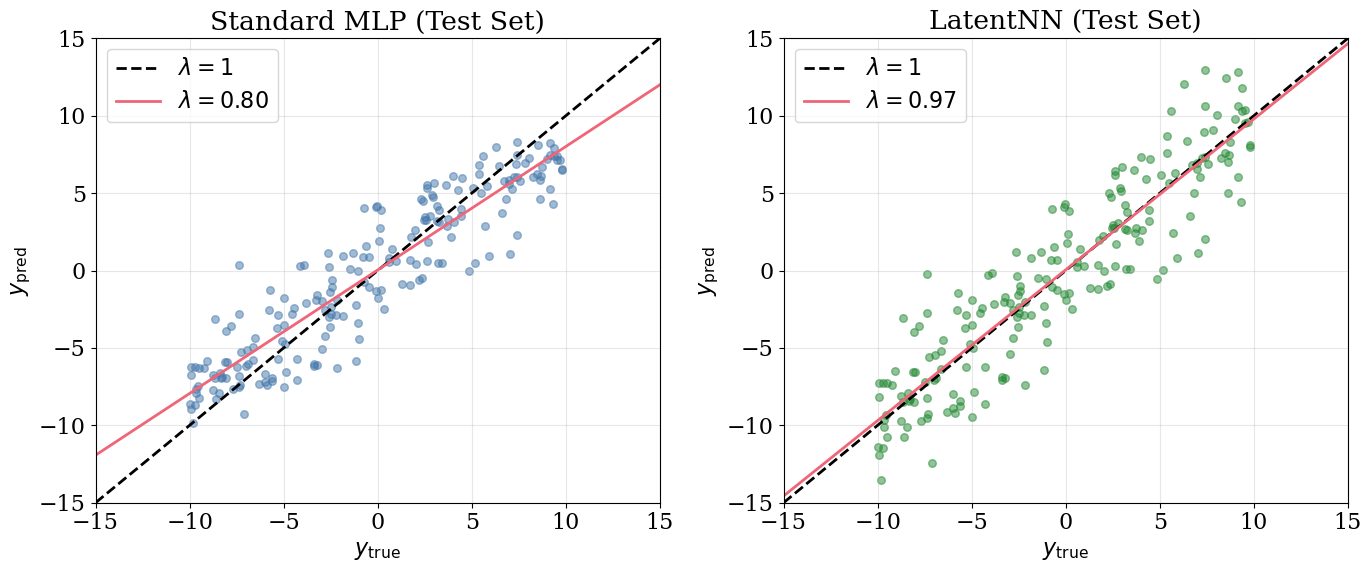

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
y_min, y_max = -15, 15

for ax, y_pred, lam, intercept, title, color in [
    (axes[0], y_pred_mlp, lam_mlp, int_mlp, 'Standard MLP (Test Set)', CB_BLUE),
    (axes[1], y_pred_latent, lam_latent, int_latent, 'LatentNN (Test Set)', CB_GREEN)
]:
    ax.scatter(test['y_true'], y_pred, alpha=0.5, s=30, c=color)
    ax.plot([y_min, y_max], [y_min, y_max], 'k--', lw=2, label='$\\lambda = 1$')
    ax.plot([y_min, y_max], [lam*y_min+intercept, lam*y_max+intercept],
            '-', color=CB_RED, lw=2, label=f'$\\lambda = {lam:.2f}$')
    ax.set_xlabel('$y_{\\mathrm{true}}$')
    ax.set_ylabel('$y_{\\mathrm{pred}}$')
    ax.set_title(title)
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 5. Training Dynamics

Examining the training process provides insight into how LatentNN achieves bias correction. The left panel shows the loss components, while the right panel tracks the attenuation factor during training.

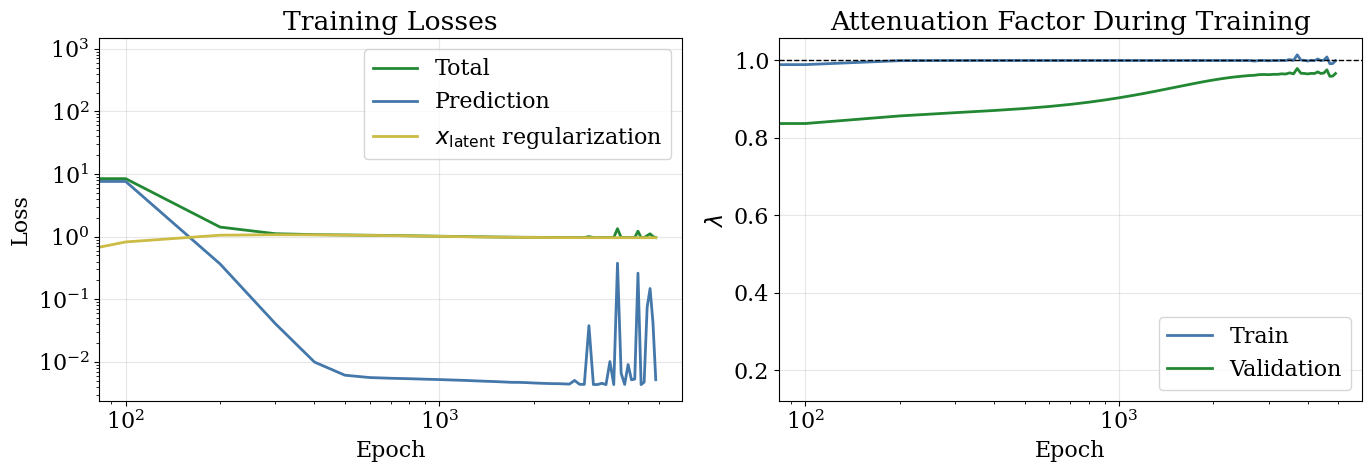

In [12]:
epochs = np.arange(0, EPOCHS, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss components
ax = axes[0]
ax.plot(epochs, losses['total'], '-', color=CB_GREEN, lw=2, label='Total')
ax.plot(epochs, losses['pred'], '-', color=CB_BLUE, lw=2, label='Prediction')
ax.plot(epochs, losses['reg'], '-', color=CB_ORANGE, lw=2, label='$x_{\\mathrm{latent}}$ regularization')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='upper right')
ax.set_title('Training Losses')

# Attenuation during training
ax = axes[1]
ax.plot(epochs, losses['lambda_train'], '-', color=CB_BLUE, lw=2, label='Train')
ax.plot(epochs, losses['lambda_val'], '-', color=CB_GREEN, lw=2, label='Validation')
ax.axhline(1.0, color='k', linestyle='--', lw=1)
ax.set_xlabel('Epoch')
ax.set_ylabel('$\\lambda$')
ax.set_xscale('log')
ax.legend(loc='lower right')
ax.set_title('Attenuation Factor During Training')

plt.tight_layout()
plt.show()

Note that the regularization loss *increases* during training. This is expected: to achieve accurate predictions, the latent values must shift from $x_{\mathrm{obs}}$ toward $x_{\mathrm{true}}$, which increases the regularization term. The optimization finds the appropriate balance between prediction accuracy and fidelity to observations.

---
## 6. Systematic Validation

We verify that LatentNN corrects attenuation across a range of input SNR values. For each SNR, we:
1. Run hyperparameter search on the validation set
2. Run 8 parallel simulations with different seeds
3. Report mean ± std of the attenuation factor on the test set


In [13]:
snr_x_values = np.array([1, 2, 3, 5, 10])
weight_decays = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
results = {'mlp': {'mean': [], 'std': []}, 'latent': {'mean': [], 'std': []}}

print(f'Running systematic comparison ({N_SIMS} simulations per SNR)...')
print('Note: HP search uses validation set; final eval uses test set')
print()

for snr_x in snr_x_values:
    # HP search using seed=42
    data_hp = generate_data(N_TRAIN + N_VAL + N_TEST, snr_x, SNR_Y, seed=42)
    train_hp = {k: v[:N_TRAIN] for k, v in data_hp.items() if isinstance(v, np.ndarray)}
    val_hp = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data_hp.items() if isinstance(v, np.ndarray)}
    sigma_x, sigma_y = data_hp['sigma_x'], data_hp['sigma_y']
    
    # LatentNN: select weight_decay by λ on validation set
    best_wd_lat, best_lam = None, 0
    for wd in weight_decays:
        torch.manual_seed(42)
        m = train_latent_mlp(train_hp['x_obs'], train_hp['y_obs'], sigma_x, sigma_y,
                             hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                             epochs=EPOCHS, lr=LR, weight_decay=wd,
                             x_val=val_hp['x_obs'], y_true_val=val_hp['y_true'])
        lam, _ = calc_lambda(val_hp['y_true'], predict_latent(m, val_hp['x_obs']))
        if best_wd_lat is None or abs(lam - 1) < abs(best_lam - 1):
            best_wd_lat, best_lam = wd, lam
    
    # MLP: select weight_decay by loss on validation set
    best_wd_mlp, best_loss = None, float('inf')
    for wd in weight_decays:
        torch.manual_seed(42)
        m = train_mlp(train_hp['x_obs'], train_hp['y_obs'],
                      hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                      epochs=EPOCHS, lr=LR, weight_decay=wd)
        y_p = predict_mlp(m, val_hp['x_obs'])
        vl = np.mean((y_p - val_hp['y_true'])**2)
        if vl < best_loss:
            best_wd_mlp, best_loss = wd, vl
    
    # Run N_SIMS parallel simulations with different seeds
    def run_sim(sim):
        data = generate_data(N_TRAIN + N_VAL + N_TEST, snr_x, SNR_Y, seed=42+sim)
        tr = {k: v[:N_TRAIN] for k, v in data.items() if isinstance(v, np.ndarray)}
        va = {k: v[N_TRAIN:N_TRAIN+N_VAL] for k, v in data.items() if isinstance(v, np.ndarray)}
        te = {k: v[N_TRAIN+N_VAL:] for k, v in data.items() if isinstance(v, np.ndarray)}
        sx, sy = data['sigma_x'], data['sigma_y']
        
        torch.manual_seed(42+sim)
        mlp = train_mlp(tr['x_obs'], tr['y_obs'],
                        hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                        epochs=EPOCHS, lr=LR, weight_decay=best_wd_mlp)
        lam_m, _ = calc_lambda(te['y_true'], predict_mlp(mlp, te['x_obs']))
        
        torch.manual_seed(42+sim)
        lat = train_latent_mlp(tr['x_obs'], tr['y_obs'], sx, sy,
                               hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                               epochs=EPOCHS, lr=LR, weight_decay=best_wd_lat,
                               x_val=va['x_obs'], y_true_val=va['y_true'])
        lam_l, _ = calc_lambda(te['y_true'], predict_latent(lat, te['x_obs']))
        return lam_m, lam_l
    
    sim_results = Parallel(n_jobs=N_JOBS)(delayed(run_sim)(s) for s in range(N_SIMS))
    mlp_lams = [r[0] for r in sim_results]
    lat_lams = [r[1] for r in sim_results]
    
    results['mlp']['mean'].append(np.mean(mlp_lams))
    results['mlp']['std'].append(np.std(mlp_lams))
    results['latent']['mean'].append(np.mean(lat_lams))
    results['latent']['std'].append(np.std(lat_lams))
    
    print(f'  SNR_x = {snr_x:2d}:  MLP λ = {np.mean(mlp_lams):.3f}±{np.std(mlp_lams):.3f},  LatentNN λ = {np.mean(lat_lams):.3f}±{np.std(lat_lams):.3f}')

Running systematic comparison (8 simulations per SNR)...
Note: HP search uses validation set; final eval uses test set

  SNR_x =  1:  MLP λ = 0.518±0.054,  LatentNN λ = 0.944±0.093
  SNR_x =  2:  MLP λ = 0.820±0.029,  LatentNN λ = 0.991±0.052
  SNR_x =  3:  MLP λ = 0.909±0.021,  LatentNN λ = 1.000±0.044
  SNR_x =  5:  MLP λ = 0.966±0.017,  LatentNN λ = 0.998±0.023
  SNR_x = 10:  MLP λ = 0.995±0.011,  LatentNN λ = 1.000±0.014


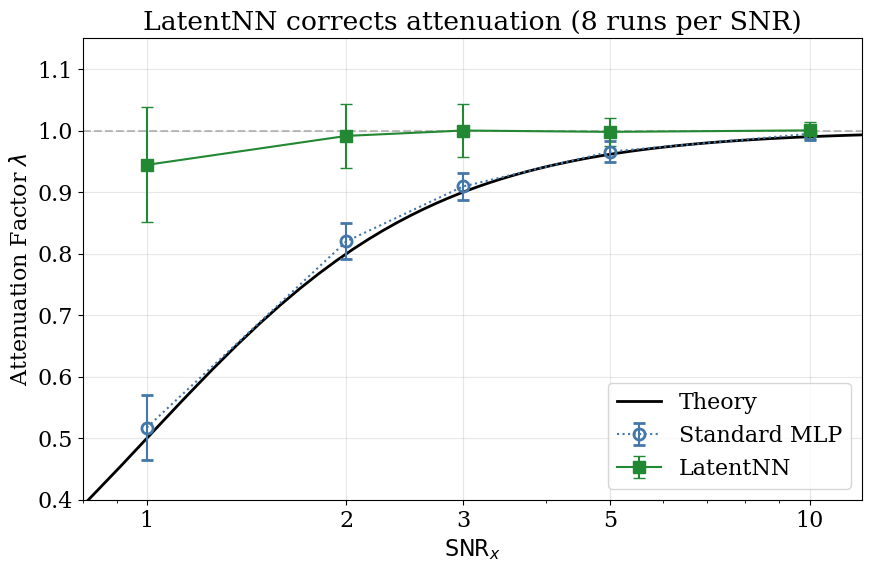

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

snr_theory = np.linspace(0.8, 12, 100)
ax.plot(snr_theory, [theoretical_attenuation(s) for s in snr_theory],
        'k-', lw=2, label='Theory')

ax.errorbar(snr_x_values, results['mlp']['mean'], yerr=results['mlp']['std'],
            fmt='o:', c=CB_BLUE, capsize=4, markersize=8, markerfacecolor='none',
            markeredgewidth=2, lw=1.5, label='Standard MLP', zorder=5)
ax.errorbar(snr_x_values, results['latent']['mean'], yerr=results['latent']['std'],
            fmt='s-', c=CB_GREEN, capsize=4, markersize=8, lw=1.5,
            label='LatentNN', zorder=5)

ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('$\\mathrm{SNR}_x$')
ax.set_ylabel('Attenuation Factor $\\lambda$')
ax.set_xscale('log')
ax.set_xlim(0.8, 12)
ax.set_xticks(snr_x_values)
ax.set_xticklabels([str(x) for x in snr_x_values])
ax.set_ylim(0.4, 1.15)
ax.legend(loc='lower right')
ax.set_title(f'LatentNN corrects attenuation ({N_SIMS} runs per SNR)')
plt.tight_layout()
plt.show()

---
## Summary

1. **Attenuation bias** causes regression models to underestimate the true relationship when inputs are measured with error. The bias depends on the input SNR as $\lambda = 1/(1 + 1/\mathrm{SNR}_x^2)$.

2. **Neural networks exhibit the same bias** as linear regression because they treat noisy observations as exact inputs. Model complexity does not help.

3. **LatentNN corrects this bias** by treating true input values as latent variables, optimizing a joint likelihood that accounts for both input and output noise.

For multivariate inputs with correlated features (e.g., spectral data), see `tutorial_multivariate.ipynb`.